In [226]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import *

In [227]:
df=pd.read_csv("mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [228]:
df.shape

(8124, 23)

In [229]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [230]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [231]:
features=['cap-surface', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type']

X = pd.get_dummies(df[features])
y = df['class']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [232]:
BNB = BernoulliNB(class_prior=[0.4, 0.6]) #A:94, FN:83
# BNB = BernoulliNB()
BNB.fit(X_train, y_train)

y_pred = BNB.predict(X_test)

In [233]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9858461538461538
Confusion Matrix:
 [[840   3]
 [ 20 762]]
Classification Report:
               precision    recall  f1-score   support

           e       0.98      1.00      0.99       843
           p       1.00      0.97      0.99       782

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



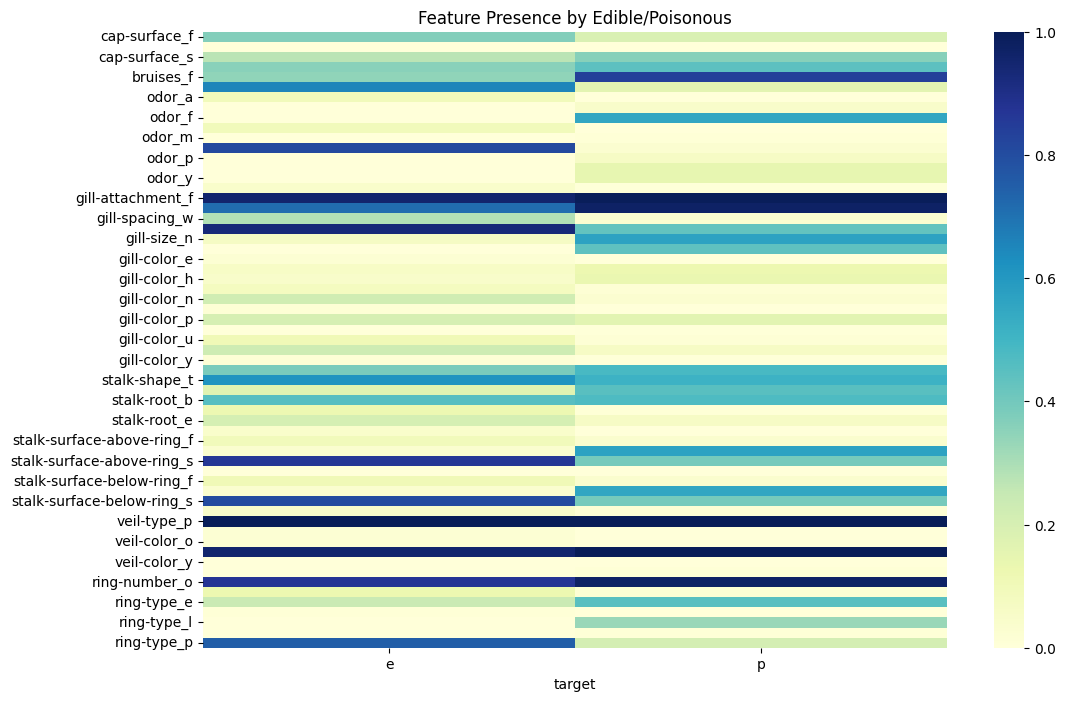

In [ ]:
import numpy as np
import seaborn as sns

feature_means = pd.DataFrame(X)
feature_means['target'] = y
feature_summary = feature_means.groupby('target').mean().T  # transpose for heatmap

plt.figure(figsize=(12,8))
sns.heatmap(feature_summary, cmap='YlGnBu')
plt.title('Feature Presence by Edible/Poisonous')
plt.show()

* This heatmap visualizes how often each feature appears in edible vs poisonous mushrooms — in simple terms, it shows which features are common or rare for each class.
* Compute mean of each binary feature for target

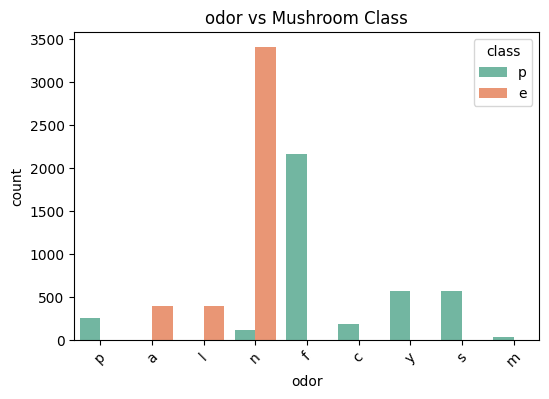

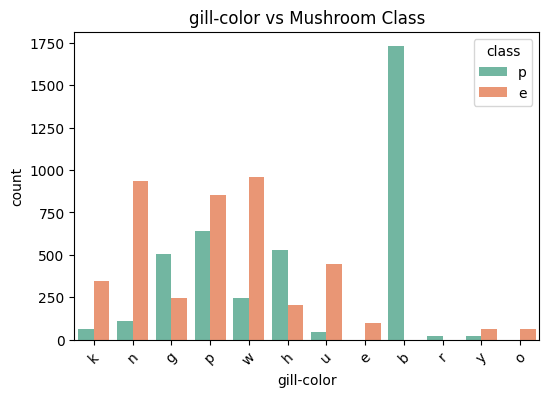

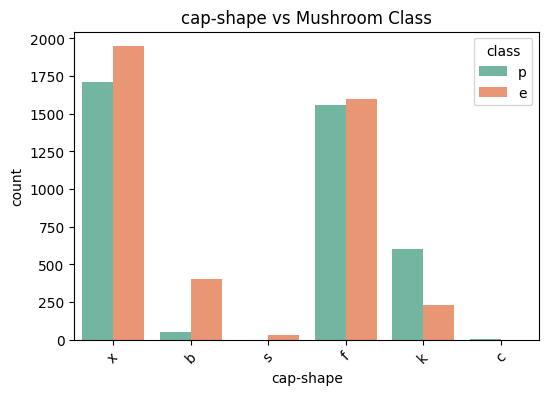

In [ ]:
categorical_features = ['odor', 'gill-color', 'cap-shape']


for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='class', palette='Set2')
    plt.title(f'{col} vs Mushroom Class')
    plt.xticks(rotation=45)
    plt.show()

* These graphs show how certain features of mushrooms relate to whether the mushroom is poisonous (p) or edible (e).
* By looking at these features, you can get a good idea if a mushroom might be poisonous or safe.

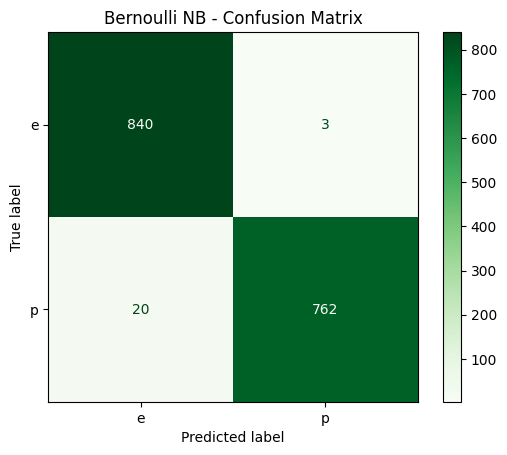

In [236]:
ConfusionMatrixDisplay.from_estimator(BNB, X_test, y_test, cmap='Greens')
plt.title('Bernoulli NB - Confusion Matrix')
plt.show()